# Exploring the RevisitOP benchmark

Loads `roxford5k` and `rparis6k` via `cbir.data.revisitop.download`, which wraps the
`galilai-group/revisitop` HF dataset script (`trust_remote_code=True`, requires
`datasets<4.0`) and asserts the loaded splits match the verified counts in
`AGENTS.md` before returning anything.

Note: the `revisitop1m` and `oxfordparis` configs in that loading script are known to
be broken (see AGENTS.md) — `download()` rejects them outright, so they are
intentionally not used here.

You can also fetch these ahead of time from the shell: `uv run cbir download --datasets roxford5k rparis6k`.

In [ ]:
from collections import Counter

import matplotlib.pyplot as plt
from PIL import ImageDraw

from cbir.data.revisitop import download

## Load roxford5k

In [ ]:
ox_query, ox_db = download("roxford5k")
print(ox_query)
print(ox_db)

roxford5k: 4993 database images, 70 queries — OK
Dataset({
    features: ['image', 'filename', 'dataset', 'query_id', 'bbx', 'easy', 'hard', 'junk'],
    num_rows: 70
})
Dataset({
    features: ['image', 'filename', 'dataset', 'query_id', 'bbx', 'easy', 'hard', 'junk'],
    num_rows: 4993
})


In [3]:
ox_query.features


{'image': Image(mode=None, decode=True, id=None),
 'filename': Value(dtype='string', id=None),
 'dataset': Value(dtype='string', id=None),
 'query_id': Value(dtype='int32', id=None),
 'bbx': Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None),
 'easy': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'hard': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'junk': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None)}

In [ ]:
example = ox_query[0]
{k: v for k, v in example.items() if k != "image"}

{'filename': 'all_souls_000013',
 'dataset': 'roxford5k',
 'query_id': 0,
 'bbx': [136.5, 34.099998474121094, 648.5, 955.7000122070312],
 'easy': [30,
  69,
  296,
  324,
  581,
  623,
  685,
  691,
  736,
  801,
  953,
  1125,
  1232,
  1318,
  1392,
  1520,
  1581,
  1619,
  1643,
  1688,
  1707,
  1754,
  2017,
  2194,
  2204,
  2221,
  2279,
  2293,
  2423,
  2588,
  2916,
  2918,
  2939,
  2956,
  3041,
  3268,
  3303,
  3313,
  3317,
  3349,
  3458,
  3534,
  3599,
  3620,
  3784,
  3797,
  3907,
  3985,
  4028,
  4035,
  4083,
  4093,
  4118,
  4157,
  4236,
  4255,
  4260,
  4290,
  4486,
  4644,
  4682,
  4900,
  4960,
  4969,
  4984],
 'hard': [9,
  92,
  185,
  232,
  322,
  511,
  606,
  660,
  690,
  795,
  871,
  1004,
  1144,
  1206,
  1256,
  1424,
  1516,
  1537,
  1687,
  1813,
  1932,
  2224,
  2287,
  2354,
  2549,
  2739,
  2847,
  3133,
  3151,
  3998,
  4052,
  4249,
  4327,
  4367,
  4493,
  4634,
  4700,
  4764],
 'junk': [72,
  258,
  275,
  355,
  383,
  503,

(np.float64(-0.5), np.float64(767.5), np.float64(1023.5), np.float64(-0.5))

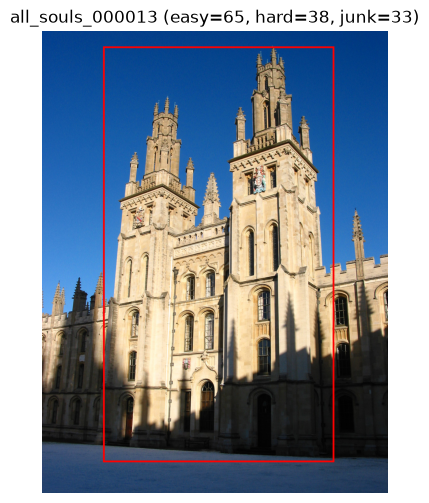

In [ ]:
# Draw the query bbox on the full image
img = example["image"].convert("RGB").copy()
draw = ImageDraw.Draw(img)
x1, y1, x2, y2 = example["bbx"]
draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
title = f"{example['filename']} (easy={len(example['easy'])}, hard={len(example['hard'])}, junk={len(example['junk'])})"
ax.set_title(title)
ax.axis("off")

queries with 0 easy positives: 2
queries with 0 hard positives: 0


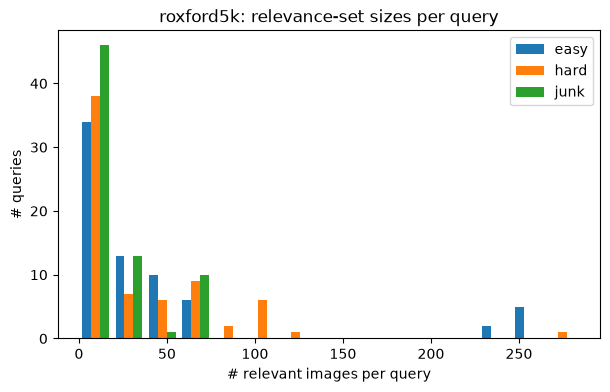

In [ ]:
# Distribution of #easy / #hard / #junk per query, and how many queries have zero easy positives
easy_counts = [len(q["easy"]) for q in ox_query]
hard_counts = [len(q["hard"]) for q in ox_query]
junk_counts = [len(q["junk"]) for q in ox_query]

print("queries with 0 easy positives:", sum(1 for c in easy_counts if c == 0))
print("queries with 0 hard positives:", sum(1 for c in hard_counts if c == 0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist([easy_counts, hard_counts, junk_counts], bins=15, label=["easy", "hard", "junk"])
ax.set_xlabel("# relevant images per query")
ax.set_ylabel("# queries")
ax.set_title("roxford5k: relevance-set sizes per query")
ax.legend()

In [7]:
Counter(ox_db["dataset"])


Counter({'roxford5k': 4993})

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

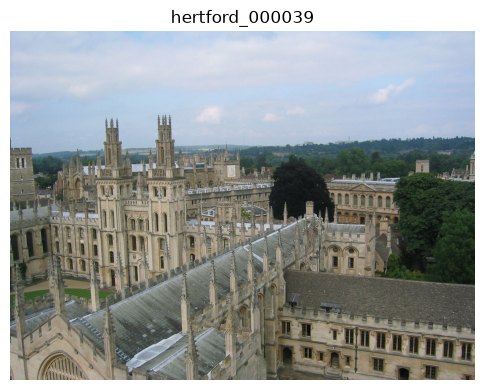

In [ ]:
# One of query 0's "easy" ground-truth matches, retrieved from the database by index
easy_id = example["easy"][10]
easy = ox_db[easy_id]
img = easy["image"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.set_title(easy["filename"])
ax.axis("off")

## Load rparis6k

In [ ]:
pa_query, pa_db = download("rparis6k")

rparis6k: 6322 database images, 70 queries — OK


(np.float64(-0.5), np.float64(1023.5), np.float64(746.5), np.float64(-0.5))

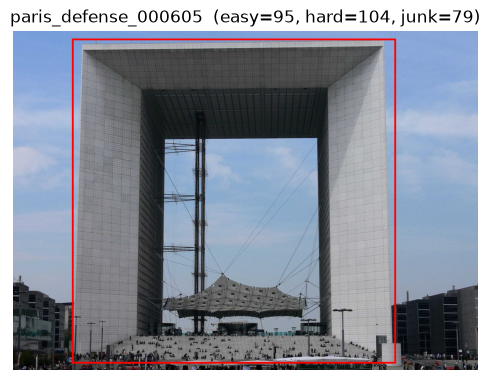

In [ ]:
pa_example = pa_query[0]
img = pa_example["image"].convert("RGB").copy()
draw = ImageDraw.Draw(img)
x1, y1, x2, y2 = pa_example["bbx"]
draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.set_title(f"{pa_example['filename']}  (easy={len(pa_example['easy'])}, hard={len(pa_example['hard'])}, junk={len(pa_example['junk'])})")
ax.axis("off")

queries with 0 easy positives: 0
queries with 0 hard positives: 0


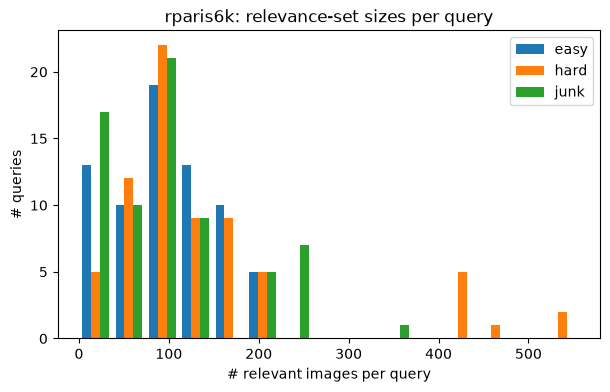

In [ ]:
easy_counts_p = [len(q["easy"]) for q in pa_query]
hard_counts_p = [len(q["hard"]) for q in pa_query]
junk_counts_p = [len(q["junk"]) for q in pa_query]

print("queries with 0 easy positives:", sum(1 for c in easy_counts_p if c == 0))
print("queries with 0 hard positives:", sum(1 for c in hard_counts_p if c == 0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist([easy_counts_p, hard_counts_p, junk_counts_p], bins=15, label=["easy", "hard", "junk"])
ax.set_xlabel("# relevant images per query")
ax.set_ylabel("# queries")
ax.set_title("rparis6k: relevance-set sizes per query")
ax.legend()